In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("features_v1.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2000, 29)

First 5 rows:


,fare_pkr,trip_duration_min,driver_rating,surge_multiplier,hour,day_of_week,month,quarter,is_weekend,is_holiday,...,vehicle_type_Sedan,vehicle_type_Van,weather_Foggy,weather_Rainy,weather_Unknown,weather_Windy,effective_fare,fare_per_min,is_peak_hour,is_night_ride
0,411.86,11.2,4.0,1.0,0,6,1,1,1,0,...,1,0,0,1,0,0,411.86,36.7732,0,1
1,664.70,21.6,4.2,1.0,6,6,1,1,1,0,...,1,0,0,0,0,0,664.70,30.7731,0,0
2,576.36,33.3,4.3,1.0,12,6,1,1,1,0,...,0,0,0,0,0,0,576.36,17.3081,0,0
3,673.60,33.7,4.2,1.0,18,6,1,1,1,0,...,0,0,1,0,0,0,673.60,19.9881,1,0
4,238.85,16.1,4.3,1.0,0,0,1,1,0,0,...,1,0,0,0,1,0,238.85,14.8354,0,1


In [3]:
print("Dataset Info:")
print(df.info())
print("\nNull values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fare_pkr            2000 non-null   float64
 1   trip_duration_min   2000 non-null   float64
 2   driver_rating       2000 non-null   float64
 3   surge_multiplier    2000 non-null   float64
 4   hour                2000 non-null   int64  
 5   day_of_week         2000 non-null   int64  
 6   month               2000 non-null   int64  
 7   quarter             2000 non-null   int64  
 8   is_weekend          2000 non-null   int64  
 9   is_holiday          2000 non-null   int64  
 10  hour_sin            2000 non-null   float64
 11  hour_cos            2000 non-null   float64
 12  month_sin           2000 non-null   float64
 13  month_cos           2000 non-null   float64
 14  city_Karachi        2000 non-null   int64  
 15  city_Lahore         2000 non-null   int64  
 16  cit

In [4]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,fare_pkr,trip_duration_min,driver_rating,surge_multiplier,hour,day_of_week,month,quarter,is_weekend,is_holiday,...,vehicle_type_Sedan,vehicle_type_Van,weather_Foggy,weather_Rainy,weather_Unknown,weather_Windy,effective_fare,fare_per_min,is_peak_hour,is_night_ride
count,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,...,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,475.436820,22.577600,4.275850,1.1752,9.000000,2.996000,5.508000,2.190000,0.286000,0.01400,...,0.301500,0.092500,0.097500,0.24000,0.010000,0.097000,561.269785,121.750524,0.250000,0.250000
std,237.810465,22.184377,0.456997,0.2879,6.709882,2.005491,3.456575,1.116478,0.452002,0.11752,...,0.459024,0.289803,0.296712,0.42719,0.099524,0.296032,327.152234,448.204368,0.433121,0.433121
min,22.860000,0.000000,2.600000,1.0000,0.000000,0.000000,1.000000,1.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,27.430000,0.000000,0.000000,0.000000
25%,303.625000,6.600000,4.000000,1.0000,4.500000,1.000000,3.000000,1.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,332.540000,12.719950,0.000000,0.000000
50%,431.880000,15.500000,4.300000,1.0000,9.000000,3.000000,5.000000,2.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,484.580000,27.951200,0.000000,0.000000
75%,612.945000,32.025000,4.600000,1.2000,13.500000,5.000000,8.000000,3.000000,1.000000,0.00000,...,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,713.097500,68.103325,0.250000,0.250000
max,1851.100000,176.600000,5.000000,2.0000,18.000000,6.000000,12.000000,4.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,2734.160000,8351.700000,1.000000,1.000000


In [5]:
# Feature Engineering: Additional derived features

# 1. Fare category (binning continuous variable into categories)
df['fare_category'] = pd.cut(df['fare_pkr'],
                              bins=[0, 200, 400, 600, 800, 2000],
                              labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 2. Duration category
df['duration_category'] = pd.cut(df['trip_duration_min'],
                                  bins=[0, 10, 30, 60, 200],
                                  labels=['Short', 'Medium', 'Long', 'Very Long'])

# 3. Rating category
df['rating_category'] = pd.cut(df['driver_rating'],
                                bins=[0, 2, 3, 4, 5],
                                labels=['Poor', 'Average', 'Good', 'Excellent'])

# 4. High surge flag (surge > 1.5 means high surge pricing)
df['is_high_surge'] = (df['surge_multiplier'] > 1.5).astype(int)

# 5. Fare efficiency score (how much fare per unit of surge)
df['fare_efficiency'] = df['fare_pkr'] / df['surge_multiplier']

print("New features added successfully!")
print("New columns:", ['fare_category', 'duration_category', 'rating_category', 'is_high_surge', 'fare_efficiency'])
print("\nUpdated shape:", df.shape)

New features added successfully!
New columns: ['fare_category', 'duration_category', 'rating_category', 'is_high_surge', 'fare_efficiency']

Updated shape: (2000, 34)


In [6]:
# One-Hot Encoding verification
# City columns (already encoded from Day 1)
city_cols = ['city_Karachi', 'city_Lahore', 'city_Peshawar', 'city_Quetta']
vehicle_cols = ['vehicle_type_SUV', 'vehicle_type_Sedan', 'vehicle_type_Van']
weather_cols = ['weather_Foggy', 'weather_Rainy', 'weather_Unknown', 'weather_Windy']

print("City OHE columns:", city_cols)
print("Vehicle OHE columns:", vehicle_cols)
print("Weather OHE columns:", weather_cols)
print("\nSample of encoded data:")
df[city_cols + vehicle_cols].head()

City OHE columns: ['city_Karachi', 'city_Lahore', 'city_Peshawar', 'city_Quetta']
Vehicle OHE columns: ['vehicle_type_SUV', 'vehicle_type_Sedan', 'vehicle_type_Van']
Weather OHE columns: ['weather_Foggy', 'weather_Rainy', 'weather_Unknown', 'weather_Windy']

Sample of encoded data:


,city_Karachi,city_Lahore,city_Peshawar,city_Quetta,vehicle_type_SUV,vehicle_type_Sedan,vehicle_type_Van
0,0,0,1,0,0,1,0
1,0,0,0,1,0,1,0
2,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0
4,0,0,0,1,0,1,0


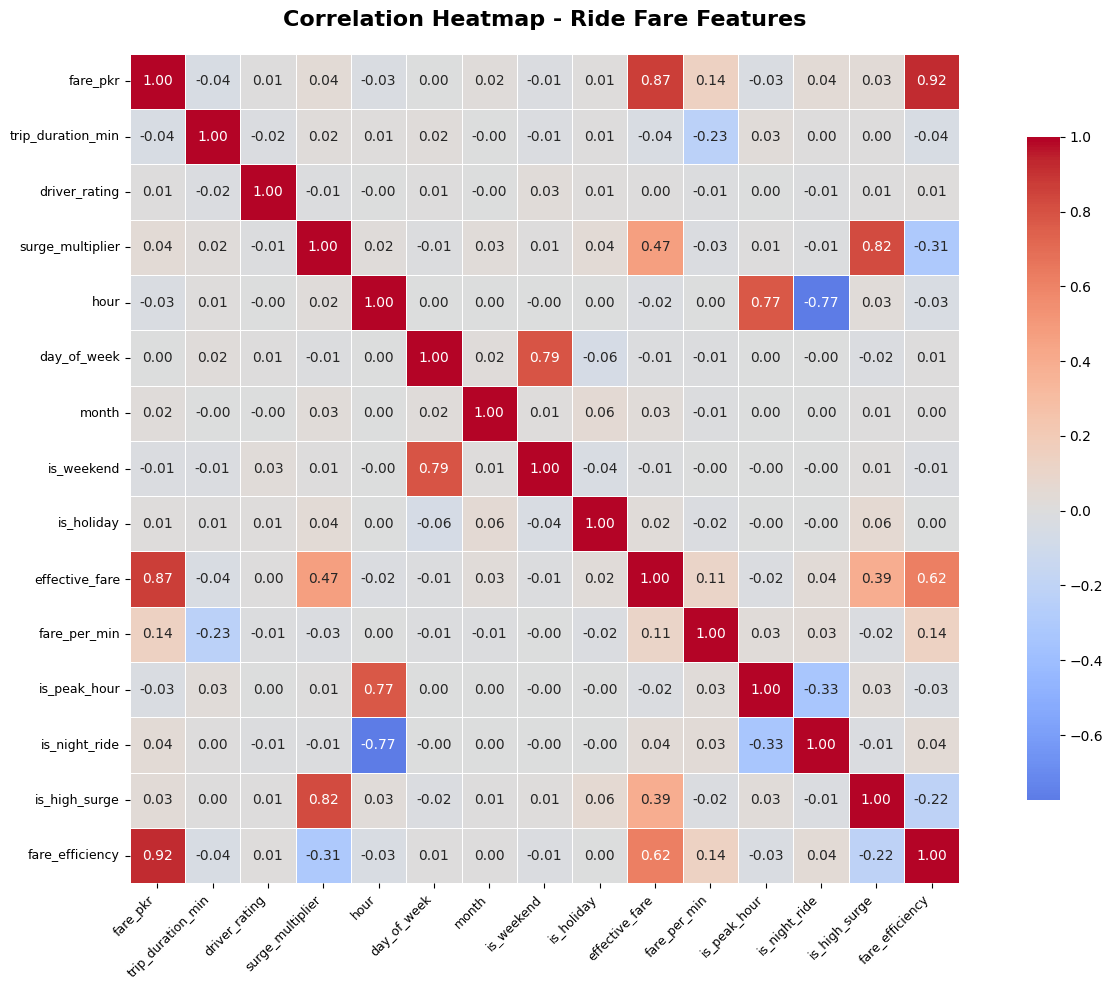

Correlation Heatmap saved!


In [7]:
# EDA Visualization 1: Correlation Heatmap
numeric_cols = ['fare_pkr', 'trip_duration_min', 'driver_rating', 'surge_multiplier',
                'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
                'effective_fare', 'fare_per_min', 'is_peak_hour', 'is_night_ride',
                'is_high_surge', 'fare_efficiency']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap - Ride Fare Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation Heatmap saved!")

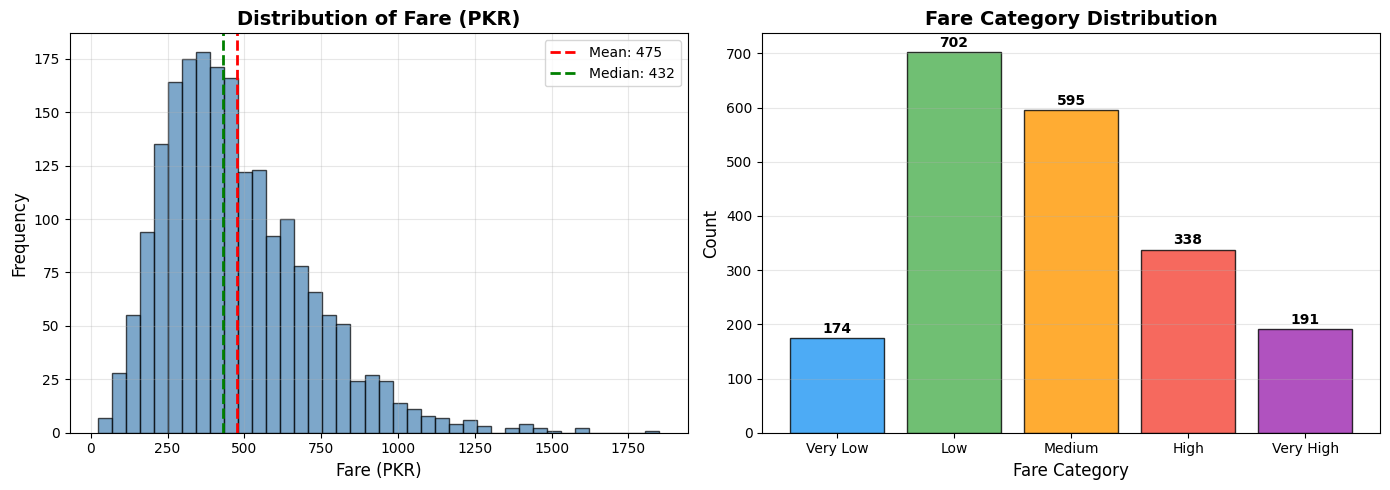

Fare Distribution Plot saved!


In [8]:
# EDA Visualization 2: Fare Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['fare_pkr'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Fare (PKR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fare (PKR)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['fare_pkr'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["fare_pkr"].mean():.0f}')
axes[0].axvline(df['fare_pkr'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["fare_pkr"].median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by fare category
fare_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
fare_counts = df['fare_category'].value_counts().reindex(fare_order)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
axes[1].bar(fare_counts.index, fare_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Fare Category Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fare Category', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')
for i, (cat, count) in enumerate(zip(fare_counts.index, fare_counts.values)):
    axes[1].text(i, count + 10, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fare Distribution Plot saved!")

/tmp/ipykernel_578/2393762520.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([non_peak_data, peak_data], labels=['Non-Peak Hours', 'Peak Hours'],


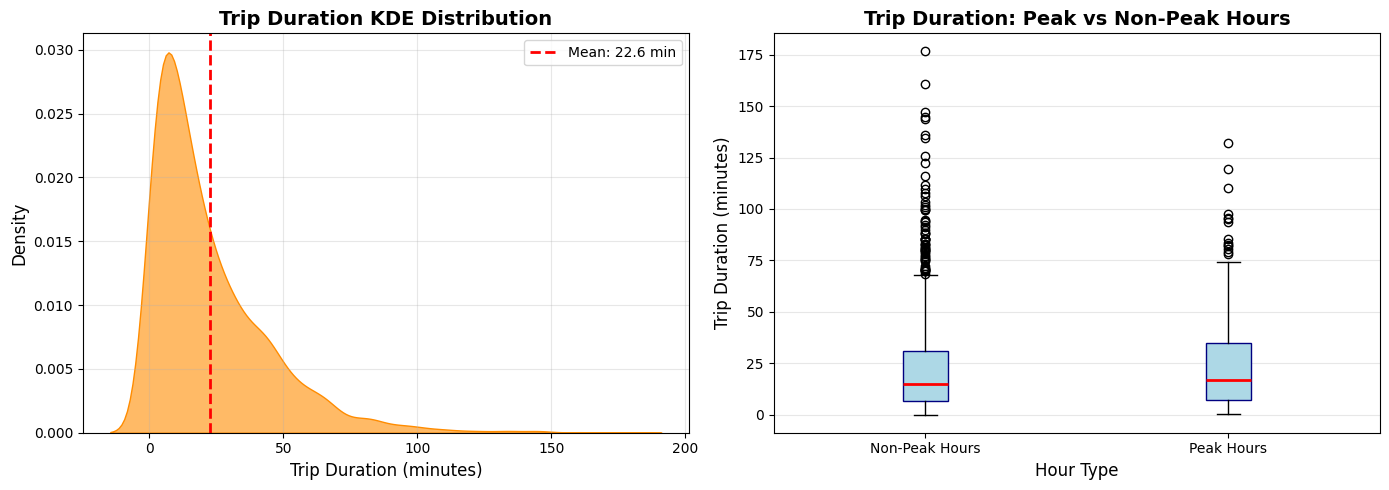

Trip Duration Distribution Plot saved!


In [9]:
# EDA Visualization 3: Trip Duration Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot for trip duration
sns.kdeplot(data=df, x='trip_duration_min', fill=True, color='darkorange', alpha=0.6, ax=axes[0])
axes[0].set_title('Trip Duration KDE Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Trip Duration (minutes)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].axvline(df['trip_duration_min'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["trip_duration_min"].mean():.1f} min')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Duration by peak vs non-peak hour
peak_data = df[df['is_peak_hour'] == 1]['trip_duration_min']
non_peak_data = df[df['is_peak_hour'] == 0]['trip_duration_min']

axes[1].boxplot([non_peak_data, peak_data], labels=['Non-Peak Hours', 'Peak Hours'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Trip Duration: Peak vs Non-Peak Hours', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour Type', fontsize=12)
axes[1].set_ylabel('Trip Duration (minutes)', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('trip_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Trip Duration Distribution Plot saved!")

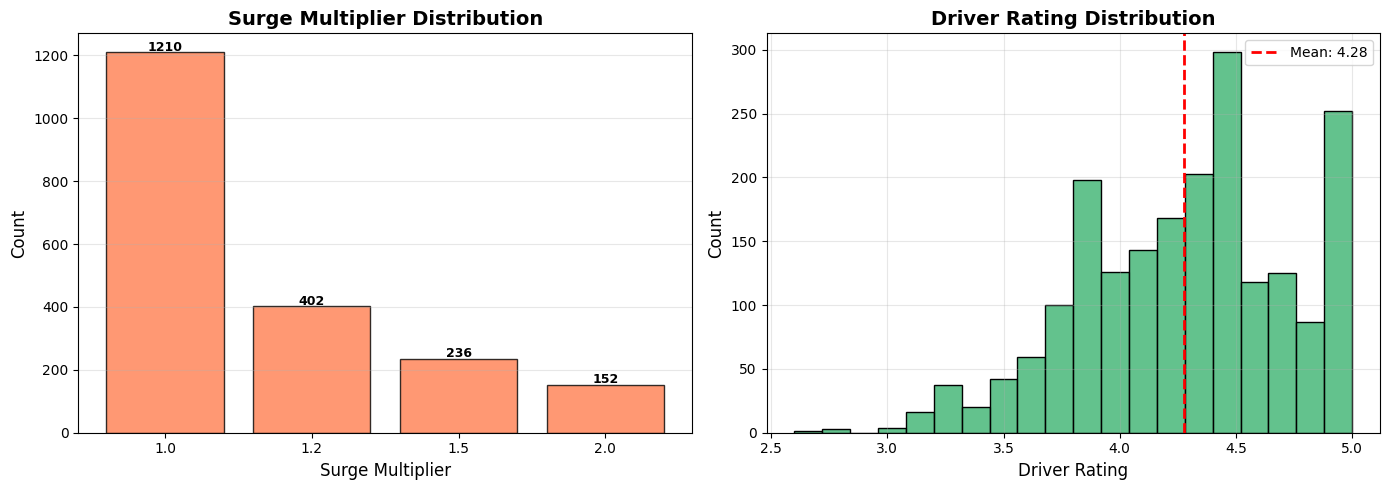

Surge & Rating Distribution saved!


In [10]:
# EDA Visualization 4: Surge Multiplier & Driver Rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Surge multiplier distribution
surge_counts = df['surge_multiplier'].value_counts().sort_index()
axes[0].bar(surge_counts.index.astype(str), surge_counts.values,
            color='coral', edgecolor='black', alpha=0.8)
axes[0].set_title('Surge Multiplier Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Surge Multiplier', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(alpha=0.3, axis='y')
for i, (idx, count) in enumerate(zip(surge_counts.index, surge_counts.values)):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold', fontsize=9)

# Driver rating distribution
sns.histplot(data=df, x='driver_rating', bins=20, color='mediumseagreen',
             edgecolor='black', alpha=0.8, ax=axes[1])
axes[1].set_title('Driver Rating Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Driver Rating', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].axvline(df['driver_rating'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["driver_rating"].mean():.2f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('surge_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Surge & Rating Distribution saved!")

In [11]:
# Business Insights from EDA

print("=" * 60)
print("KEY BUSINESS INSIGHTS FROM EDA")
print("=" * 60)

# Insight 1: Correlation between fare and duration
fare_duration_corr = df['fare_pkr'].corr(df['trip_duration_min'])
print(f"\n1. Fare vs Trip Duration Correlation: {fare_duration_corr:.3f}")
print("   -> Longer trips significantly increase fare cost")

# Insight 2: Peak hour fare impact
peak_avg = df[df['is_peak_hour'] == 1]['fare_pkr'].mean()
non_peak_avg = df[df['is_peak_hour'] == 0]['fare_pkr'].mean()
print(f"\n2. Average Fare - Peak Hours: PKR {peak_avg:.0f}")
print(f"   Average Fare - Non-Peak Hours: PKR {non_peak_avg:.0f}")
print(f"   -> Peak hours cost {((peak_avg - non_peak_avg)/non_peak_avg * 100):.1f}% more")

# Insight 3: Weekend vs weekday
weekend_avg = df[df['is_weekend'] == 1]['fare_pkr'].mean()
weekday_avg = df[df['is_weekend'] == 0]['fare_pkr'].mean()
print(f"\n3. Average Fare - Weekends: PKR {weekend_avg:.0f}")
print(f"   Average Fare - Weekdays: PKR {weekday_avg:.0f}")

# Insight 4: Surge impact
print(f"\n4. High Surge rides (>1.5x): {df['is_high_surge'].sum()} out of {len(df)}")
print(f"   ({df['is_high_surge'].mean()*100:.1f}% of all rides)")

# Insight 5: City distribution
city_mapping = {'city_Karachi': 'Karachi', 'city_Lahore': 'Lahore',
                'city_Peshawar': 'Peshawar', 'city_Quetta': 'Quetta'}
for col, city in city_mapping.items():
    count = df[col].sum()
    pct = count/len(df)*100
    print(f"   {city}: {count} rides ({pct:.1f}%)")

print("\n" + "=" * 60)

KEY BUSINESS INSIGHTS FROM EDA

1. Fare vs Trip Duration Correlation: -0.044
   -> Longer trips significantly increase fare cost

2. Average Fare - Peak Hours: PKR 463
   Average Fare - Non-Peak Hours: PKR 480
   -> Peak hours cost -3.6% more

3. Average Fare - Weekends: PKR 471
   Average Fare - Weekdays: PKR 477

4. High Surge rides (>1.5x): 152 out of 2000
   (7.6% of all rides)
   Karachi: 415 rides (20.8%)
   Lahore: 401 rides (20.1%)
   Peshawar: 396 rides (19.8%)
   Quetta: 409 rides (20.4%)



In [12]:
# Export final feature-engineered dataset
# Drop non-numeric new columns before saving (keep clean ML-ready format)
df_save = df.drop(columns=['fare_category', 'duration_category', 'rating_category'])
df_save.to_csv("features_v1.csv", index=False)

print("Final dataset exported as features_v1.csv")
print("Final shape:", df_save.shape)
print("\nAll columns in final dataset:")
for col in df_save.columns:
    print(f"  - {col}")

Final dataset exported as features_v1.csv
Final shape: (2000, 31)

All columns in final dataset:
  - fare_pkr
  - trip_duration_min
  - driver_rating
  - surge_multiplier
  - hour
  - day_of_week
  - month
  - quarter
  - is_weekend
  - is_holiday
  - hour_sin
  - hour_cos
  - month_sin
  - month_cos
  - city_Karachi
  - city_Lahore
  - city_Peshawar
  - city_Quetta
  - vehicle_type_SUV
  - vehicle_type_Sedan
  - vehicle_type_Van
  - weather_Foggy
  - weather_Rainy
  - weather_Unknown
  - weather_Windy
  - effective_fare
  - fare_per_min
  - is_peak_hour
  - is_night_ride
  - is_high_surge
  - fare_efficiency
